Evaluate simple linear regression

## Introduction

We will use simple linear regression to explore the relationship between two continuous variables. 
We will perform a complete simple linear regression analysis, which includes creating and fitting a model, checking model assumptions, analyzing model performance, interpreting model coefficients, and communicating results to stakeholders.

## Step 1: Imports

### Import packages

In [1]:
# Import pandas, pyplot from matplotlib, and seaborn.

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Import the statsmodel module and the ols function

Import the `statsmodels.api` Python module using its common abbreviation, `sm`, along with the `ols()` function from `statsmodels.formula.api`.

In [2]:

import statsmodels.api as sm
from statsmodels.formula.api import ols

### Load the dataset

In [3]:
df = pd.read_csv("advertising_and_sales_clean.csv",delimiter=',')
df

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18
...,...,...,...,...,...
4541,26000.0,4472.36,717.09,Micro,94685.87
4542,71000.0,20610.69,6545.57,Nano,249101.92
4543,44000.0,19800.07,5096.19,Micro,163631.46
4544,71000.0,17534.64,1940.87,Macro,253610.41


## Step 2: Data exploration

### Familiarize yourself with the data's features

Starting with an exploratory data analysis 

The features in the data are:
* TV promotion budget (in millions of dollars)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)

Each row corresponds to an independent marketing promotion where the business invests in `TV`, `Social_Media`, and `Radio` promotions to increase `Sales`.

In [4]:
df.shape

(4546, 5)

### Explore the independent variables

There are three continuous independent variables: `TV`, `Radio`, and `Social_Media`.
To understand how heavily the business invests in each promotion type, use `describe()` to generate descriptive statistics for these three variables.

In [10]:
df.describe()

,tv,radio,social_media,sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54062.912451,18157.533110,3323.472829,192413.332112
std,26104.941838,9663.259642,2211.253915,93019.873216
min,10000.000000,0.680000,0.030000,31199.410000
25%,32000.000000,10555.355000,1530.822500,112434.610000
50%,53000.000000,17859.515000,3055.565000,188963.680000
75%,77000.000000,25640.605000,4804.922500,272324.240000
max,100000.000000,48871.160000,13981.660000,364079.750000


### Explore the dependent variable

Before fitting the model, we'll make sure the `Sales` for each promotion (i.e., row) is present. 
If the `Sales` in a row is missing, that row isn't of much value to the simple linear regression model.

Display the percentage of missing values in the `Sales` column in the DataFrame `data`.

In [18]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('advertising_and_sales_clean.csv')

# Calculate the number of missing values in the 'sales' column
missing_sales_count = df['sales'].isnull().sum()

# Calculate the total number of rows in the DataFrame
total_rows = len(df)

# Calculate the percentage of missing values
percentage_missing_sales = (missing_sales_count / total_rows) * 100

print(f"Percentage of missing values in the 'sales' column: {percentage_missing_sales:.2f}%")

Percentage of missing values in the 'sales' column: 0.00%


### Remove the missing data

Remove all rows in the data from which `Sales` is missing.

In [19]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('advertising_and_sales_clean.csv')

# Remove rows where 'sales' column has missing values
df_cleaned = df.dropna(subset=['sales'])

# Save the cleaned DataFrame to a new CSV file
df_cleaned.to_csv('advertising_and_sales_cleaned_no_missing_sales.csv', index=False)

### Visualize the sales distribution

Create a histogram to visualize the distribution of `Sales`.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


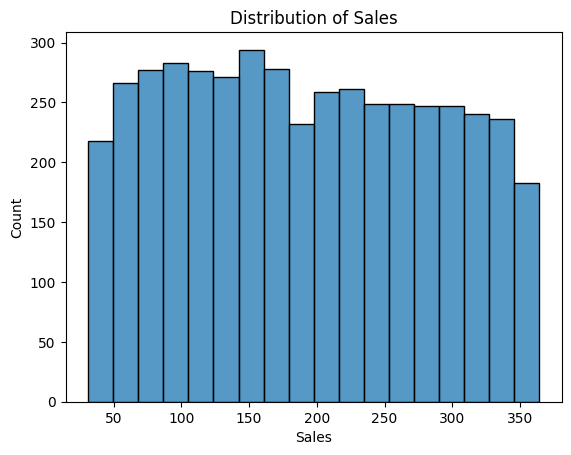

In [8]:
# Create a histogram of the Sales.
sns.histplot(data['Sales'])

# Add a title
plt.title("Distribution of Sales")
plt.show()


## Step 3: Model building

Now, we'll create a pairplot to visualize the relationships between pairs of variables in the data. 
We'll  use this to visually determine which variable has the strongest linear relationship with `Sales`. 
This will help to select the X variable for the simple linear regression.

We'll select TV for linear regression model as it's showing tight linear relationship.

### Build and fit the model

In [10]:
# Define the OLS formula.

ols_formula = "Sales ~ TV"

# Create an OLS model.

OLS = ols(formula=ols_formula, data=data)

# Fit the model.

model = OLS.fit()

# Save the results summary.

results = model.summary()

# Display the model results.

print(results)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Thu, 04 Jul 2024   Prob (F-statistic):               0.00
Time:                        06:56:16   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

### Check model assumptions

To justify using simple linear regression, check that the four linear regression assumptions are not violated.
These assumptions are:

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Model assumption: Linearity

The linearity assumption requires a linear relationship between the independent and dependent variables. 
Check this assumption by creating a scatterplot comparing the independent variable with the dependent variable. 

We'll create a scatterplot comparing the selected X variable with the dependent variable.

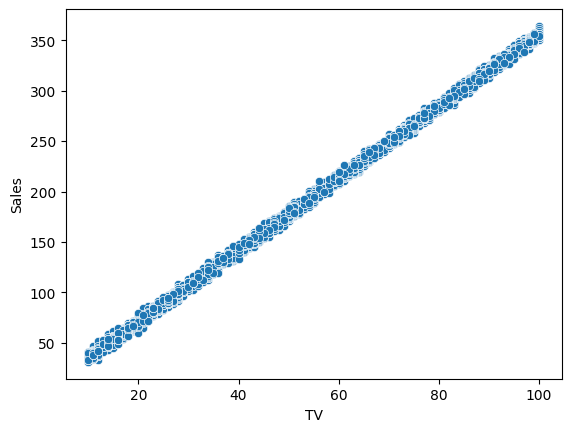

In [11]:
# Create a scatterplot comparing X and Sales (Y).

sns.scatterplot(x = data['TV'], y=data['Sales']);
plt.show();


**QUESTION:** Is the linearity assumption met?
Yes, definitely.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

The normality assumption states that the errors are normally distributed.

We'll create two plots to check this assumption:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


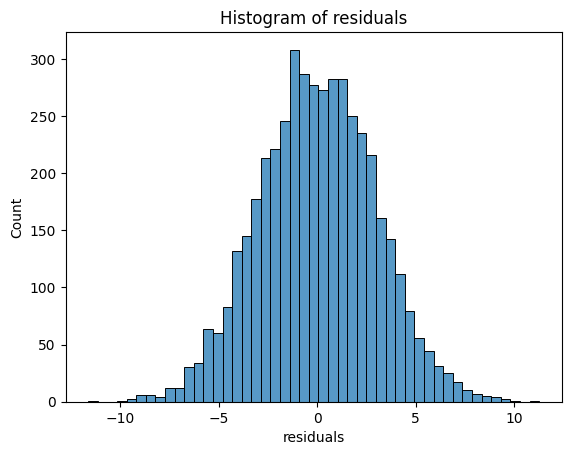

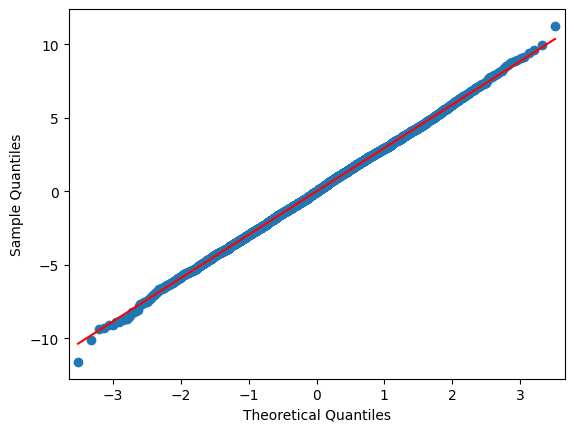

In [12]:
# Calculate the residuals.

residuals = model.resid


# Create a histogram with the residuals.
figure = sns.histplot(residuals)


# Set the x label of the residual plot.
figure.set_xlabel("residuals")

# Set the title of the residual plot.
figure.set_title("Histogram of residuals")

# Create a Q-Q plot of the residuals.
figure2 = sm.qqplot(residuals, line='s')


### Model assumption: Homoscedasticity

The **homoscedasticity (constant variance) assumption** is that the residuals have a constant variance for all values of `X`.

We'll check this by creating a scatterplot with the fitted values and residuals. 
Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

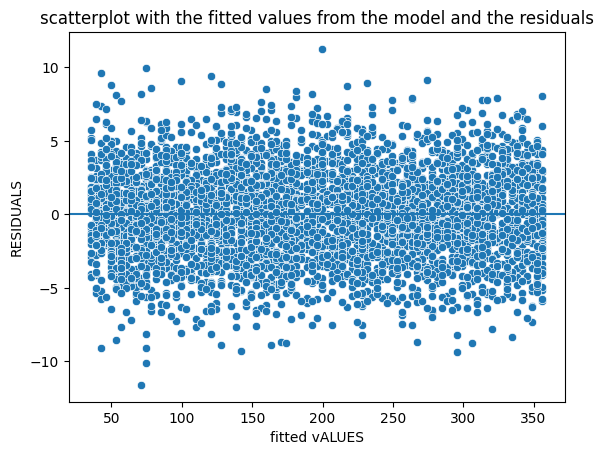

In [13]:
# Create a scatterplot with the fitted values from the model and the residuals.

X = data['TV']
fitted_value = model.predict()
figure = sns.scatterplot(x= fitted_value, y= residuals)

# Set the x-axis label.
figure.set_xlabel("fitted vALUES")
# Set the y-axis label.
figure.set_ylabel("RESIDUALS")
# Set the title.
figure.set_title("scatterplot with the fitted values from the model and the residuals")
# Add a line at y = 0 to visualize the variance of residuals above and below 0.
figure.axhline(0)

# Show the plot.
plt.show()

**QUESTION:** Is the homoscedasticity assumption met?.
Yes, as the fitted values are well distributed . and do not have any correlation among each other.

## Step 4: Results and evaluation

### Display the OLS regression results

If the linearity assumptions are met, we can interpret the model results accurately.

In [14]:
# Display the model_results

print(results)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Thu, 04 Jul 2024   Prob (F-statistic):               0.00
Time:                        06:56:16   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

### Measure the uncertainty of the coefficient estimates

Model coefficients are estimated. This means there is an amount of uncertainty in the estimate. A p-value and $95\%$ confidence interval are provided with each coefficient to quantify the uncertainty for that coefficient estimate.
